# Trader Performance vs. Bitcoin Market Sentiment
### Hyperliquid Historical Trades x Fear & Greed Index

**Goal:** Explore whether trader performance (PnL, win rate, position sizing, direction)
differs systematically between Fear and Greed market regimes, and surface actionable
patterns for a trading strategy.

**Datasets**
1. `fear_greed_index.csv` - daily Fear/Greed classification (2018-2025)
2. `historical_data.csv` - Hyperliquid trade-level execution data

**Note on file paths:** update `TRADER_FILE` below to point at your full trade history CSV.
This notebook currently runs against a small sample so the pipeline can be verified end-to-end.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

FEAR_GREED_FILE = 'data/fear_greed_index.csv'
TRADER_FILE = 'data/historical_data.csv'   # <-- replace with your full CSV filename


## 1. Load the data

In [58]:
fg = pd.read_csv(FEAR_GREED_FILE)
print(fg.shape)
fg.head()


(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [59]:
trades = pd.read_csv(TRADER_FILE)
print(trades.shape)
trades.head()


(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [60]:
trades.dtypes


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

## 2. Clean the Fear/Greed dataset

The `date` column is already a clean daily date; we just parse it and keep the columns we need.

In [61]:
fg['date'] = pd.to_datetime(fg['date'])
fg = fg[['date', 'value', 'classification']].rename(columns={'classification': 'sentiment'})
fg = fg.sort_values('date').reset_index(drop=True)
print('Date range:', fg['date'].min(), '->', fg['date'].max())
fg['sentiment'].value_counts()


Date range: 2018-02-01 00:00:00 -> 2025-05-02 00:00:00


sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

## 3. Clean the Hyperliquid trade data

Key cleaning steps:
- Standardize column names.
- Parse `Timestamp IST` as a real datetime (format is `DD-MM-YYYY HH:MM`, dayfirst).
- **Timezone alignment (this is the mismatch you flagged):** the Fear/Greed index is a
  daily value, almost certainly keyed to UTC calendar days. Our trade timestamps are in
  IST (UTC+5:30). If we just strip the date off the IST timestamp, trades that happen
  late at night IST can actually belong to a *different* UTC calendar day, and would get
  joined to the wrong sentiment label. So we convert IST -> UTC first, then take the date.
- Drop exact duplicate rows and check for missing values / obvious bad values (e.g. zero
  or negative Size USD).


In [62]:
trades.columns = [c.strip() for c in trades.columns]
trades = trades.rename(columns={
    'Account': 'account',
    'Coin': 'coin',
    'Execution Price': 'exec_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'timestamp_ist',
    'Start Position': 'start_position',
    'Direction': 'direction',
    'Closed PnL': 'closed_pnl',
    'Transaction Hash': 'tx_hash',
    'Order ID': 'order_id',
    'Crossed': 'crossed',
    'Fee': 'fee',
    'Trade ID': 'trade_id',
    'Timestamp': 'timestamp_epoch_ms'
})
trades.head()


,account,coin,exec_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,tx_hash,order_id,crossed,fee,trade_id,timestamp_epoch_ms
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [63]:
# Parse IST timestamp (dayfirst: DD-MM-YYYY HH:MM), localize to IST, convert to UTC
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['timestamp_ist'] = trades['timestamp_ist'].dt.tz_localize('Asia/Kolkata')
trades['timestamp_utc'] = trades['timestamp_ist'].dt.tz_convert('UTC')

# Two candidate join dates so we can compare the effect of the timezone fix
trades['date_ist_naive'] = trades['timestamp_ist'].dt.tz_localize(None).dt.normalize()
trades['date_utc'] = trades['timestamp_utc'].dt.tz_localize(None).dt.normalize()

mismatch = (trades['date_ist_naive'] != trades['date_utc']).sum()
print(f"Trades whose calendar day shifts once converted to UTC: {mismatch} / {len(trades)}")
trades[['timestamp_ist','timestamp_utc','date_ist_naive','date_utc']].head()


Trades whose calendar day shifts once converted to UTC: 53322 / 211224


,timestamp_ist,timestamp_utc,date_ist_naive,date_utc
0,2024-12-02 22:50:00+05:30,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02
1,2024-12-02 22:50:00+05:30,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02
2,2024-12-02 22:50:00+05:30,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02
3,2024-12-02 22:50:00+05:30,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02
4,2024-12-02 22:50:00+05:30,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02


In [64]:
# Basic quality checks
print('Duplicate rows:', trades.duplicated().sum())
print('Missing values per column:')
print(trades.isna().sum())
print()
print('Rows with non-positive Size USD:', (trades['size_usd'] <= 0).sum())
print('Rows with non-positive Execution Price:', (trades['exec_price'] <= 0).sum())

trades = trades.drop_duplicates()


Duplicate rows: 0
Missing values per column:
account               0
coin                  0
exec_price            0
size_tokens           0
size_usd              0
side                  0
timestamp_ist         0
start_position        0
direction             0
closed_pnl            0
tx_hash               0
order_id              0
crossed               0
fee                   0
trade_id              0
timestamp_epoch_ms    0
timestamp_utc         0
date_ist_naive        0
date_utc              0
dtype: int64

Rows with non-positive Size USD: 43
Rows with non-positive Execution Price: 0


## 4. Merge trades with sentiment (on the corrected UTC date)

We join on `date_utc` - the day-boundary-corrected date - rather than the naive IST date.
This is the fix for the "we don't get the same date data" issue: without it, some trades
near midnight IST would be tagged with the wrong sentiment regime.


In [65]:
merged = trades.merge(fg, left_on='date_utc', right_on='date', how='left')

unmatched = merged['sentiment'].isna().sum()
print(f"Trades with no matching sentiment date: {unmatched} / {len(merged)}")
if unmatched > 0:
    print('This usually means the trade date falls outside the Fear/Greed index date range,')
    print('or the sample only contains a few days of trades (as in this test sample).')

merged.head()


Trades with no matching sentiment date: 0 / 211224


,account,coin,exec_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,tx_hash,order_id,crossed,fee,trade_id,timestamp_epoch_ms,timestamp_utc,date_ist_naive,date_utc,date,value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00+05:30,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02,2024-12-02,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00+05:30,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02,2024-12-02,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00+05:30,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02,2024-12-02,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00+05:30,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02,2024-12-02,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00+05:30,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 17:20:00+00:00,2024-12-02,2024-12-02,2024-12-02,80,Extreme Greed


**On your full dataset**, re-run the cell above and check the `unmatched` count.
- If it's 0 or near-0 -> good, most trades fall inside the sentiment index's date coverage.
- If it's large -> check whether the trader data's date range extends beyond
  `fg['date'].min()` / `fg['date'].max()` (printed in section 2). Hyperliquid launched in 2023,
  so if your trade data goes earlier than that, or the Fear/Greed file's coverage ends
  before your most recent trades, that gap is expected and should just be reported, not
  treated as an error.


In [66]:
print('Fear/Greed coverage:', fg['date'].min().date(), '->', fg['date'].max().date())
print('Trade data coverage:  ', trades['date_utc'].min().date(), '->', trades['date_utc'].max().date())


Fear/Greed coverage: 2018-02-01 -> 2025-05-02
Trade data coverage:   2023-04-30 -> 2025-05-01


## 5. Exploratory Analysis: Performance by Sentiment

Only rows with `closed_pnl` populated represent a closed trade's realized PnL; many rows
in Hyperliquid fill data are partial fills of the same order with `closed_pnl = 0` until
a position is actually closed. We treat every row as a fill for volume/side stats, but
for PnL-specific stats we look at the distribution of `closed_pnl` directly.

In [67]:
daily = merged.groupby('date_utc').agg(
    total_pnl=('closed_pnl', 'sum'),
    n_trades=('closed_pnl', 'count'),
    avg_size_usd=('size_usd', 'mean'),
    sentiment=('sentiment', 'first'),
    sentiment_value=('value', 'first')
).reset_index()
daily.head()


,date_utc,total_pnl,n_trades,avg_size_usd,sentiment,sentiment_value
0,2023-04-30,0.000000,3,159.000000,Greed,60
1,2023-12-04,0.000000,9,5556.203333,Greed,74
2,2023-12-13,-281.804639,3,16926.133333,Greed,65
3,2023-12-14,51.737868,10,7303.490000,Greed,72
4,2023-12-16,329.708097,11,8379.370000,Greed,67


In [68]:
pnl_by_sentiment = merged.groupby('sentiment')['closed_pnl'].agg(['mean','median','sum','count'])
pnl_by_sentiment


,mean,median,sum,count
sentiment,,,,
Extreme Fear,50.337228,0.0,1.072334e+06,21303
Extreme Greed,65.085144,0.0,2.615121e+06,40180
Fear,46.626827,0.0,2.868016e+06,61510
Greed,50.124579,0.0,2.439463e+06,48668
Neutral,32.910163,0.0,1.302025e+06,39563


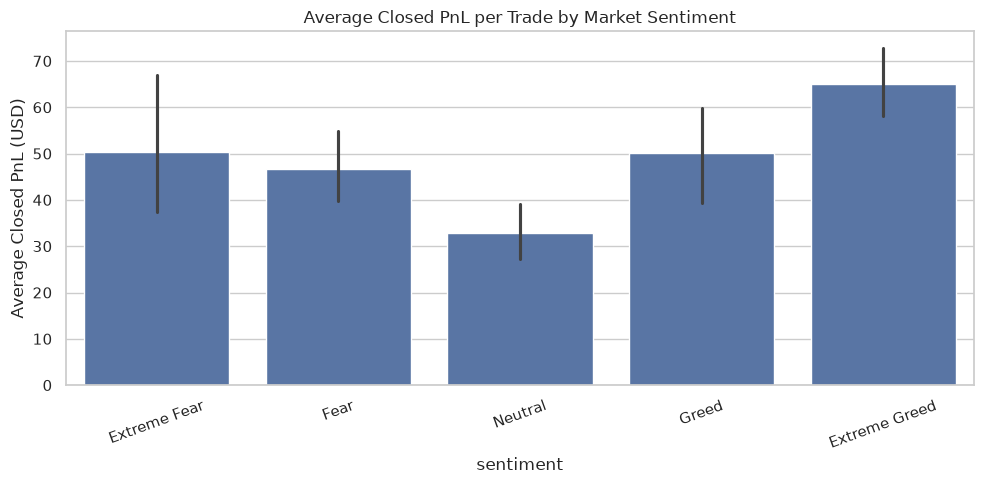

In [69]:
fig, ax = plt.subplots()
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
present_order = [o for o in order if o in merged['sentiment'].dropna().unique()]
sns.barplot(data=merged, x='sentiment', y='closed_pnl', order=present_order, estimator=np.mean, ax=ax)
ax.set_title('Average Closed PnL per Trade by Market Sentiment')
ax.set_ylabel('Average Closed PnL (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [70]:
merged['is_win'] = merged['closed_pnl'] > 0
win_rate = merged.groupby('sentiment')['is_win'].mean().reindex(present_order)
win_rate


sentiment
Extreme Fear     0.417875
Fear             0.420663
Neutral          0.362510
Greed            0.393195
Extreme Greed    0.463265
Name: is_win, dtype: float64

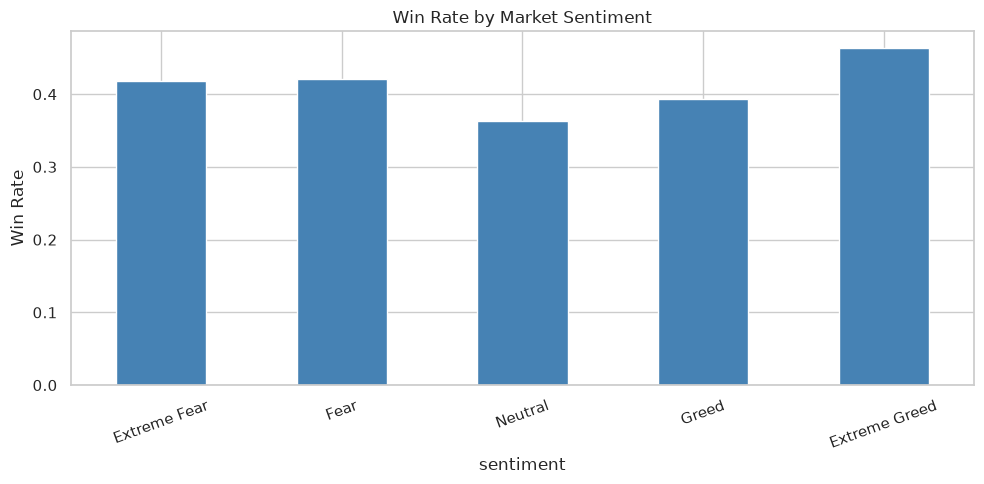

In [71]:
fig, ax = plt.subplots()
win_rate.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Win Rate by Market Sentiment')
ax.set_ylabel('Win Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


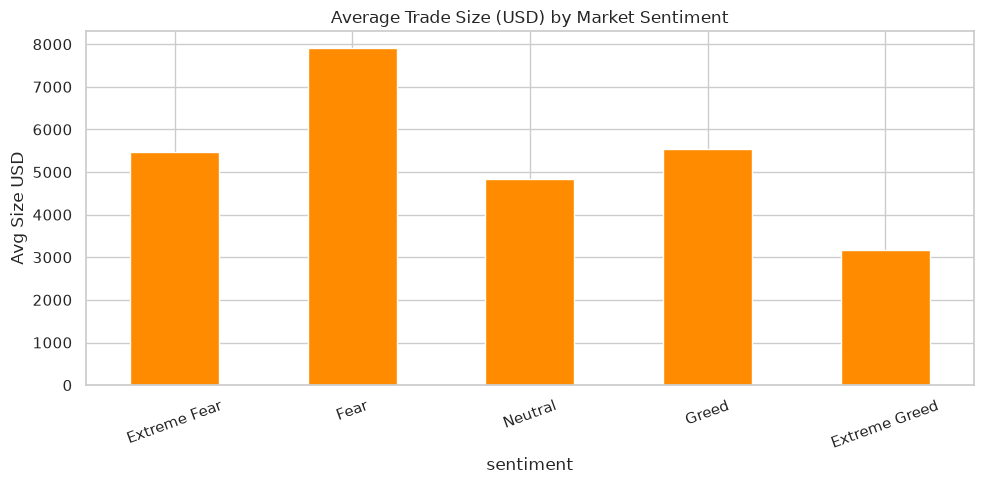

In [72]:
size_by_sentiment = merged.groupby('sentiment')['size_usd'].mean().reindex(present_order)
fig, ax = plt.subplots()
size_by_sentiment.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Average Trade Size (USD) by Market Sentiment')
ax.set_ylabel('Avg Size USD')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [73]:
direction_sentiment = pd.crosstab(merged['sentiment'], merged['direction'], normalize='index')
direction_sentiment


direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
sentiment,,,,,,,,,,,,
Extreme Fear,0.000000,0.032390,0.334742,0.150026,0.000000,0.000235,0.283669,0.150871,0.047693,0.000000,0.000235,0.000141
Extreme Greed,0.000000,0.126779,0.180562,0.163489,0.000000,0.000174,0.165605,0.185490,0.176829,0.000000,0.000274,0.000796
Fear,0.000000,0.053536,0.280085,0.148903,0.000000,0.000244,0.273988,0.185531,0.056788,0.000000,0.000244,0.000683
Greed,0.000164,0.100600,0.151311,0.227686,0.000021,0.000370,0.163845,0.230131,0.124127,0.000021,0.000596,0.001130
Neutral,0.000000,0.069332,0.245179,0.151859,0.000000,0.000303,0.312691,0.163334,0.056795,0.000000,0.000253,0.000253


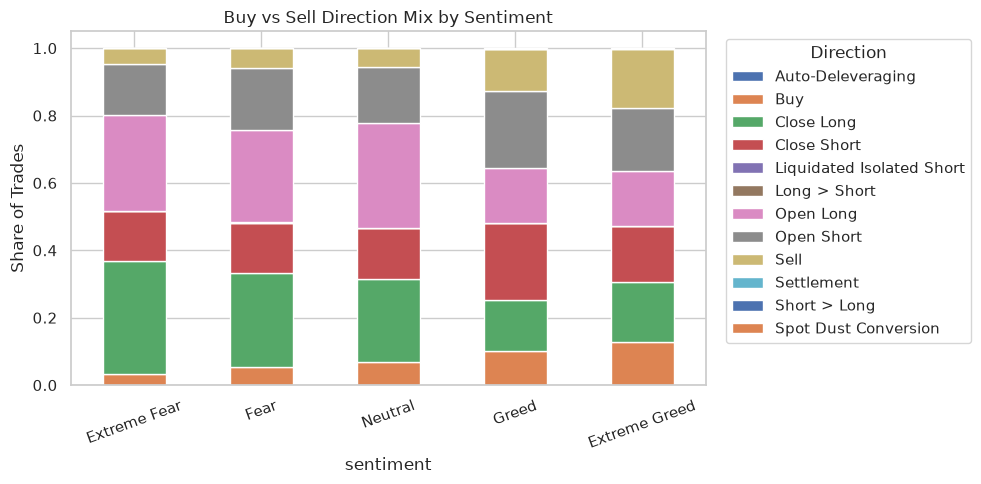

In [74]:
fig, ax = plt.subplots()
direction_sentiment.reindex(present_order).plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Buy vs Sell Direction Mix by Sentiment')
ax.set_ylabel('Share of Trades')
plt.xticks(rotation=20)
plt.legend(title='Direction', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


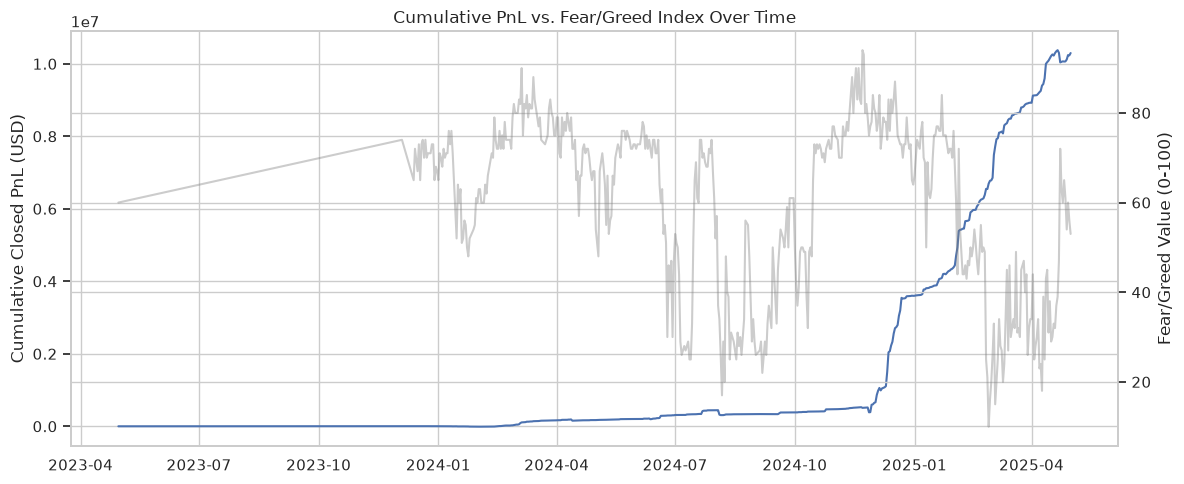

In [75]:
fig, ax = plt.subplots(figsize=(12,5))
daily_sorted = daily.sort_values('date_utc')
ax.plot(daily_sorted['date_utc'], daily_sorted['total_pnl'].cumsum(), label='Cumulative PnL')
ax2 = ax.twinx()
ax2.plot(daily_sorted['date_utc'], daily_sorted['sentiment_value'], color='gray', alpha=0.4, label='Fear/Greed Value')
ax.set_title('Cumulative PnL vs. Fear/Greed Index Over Time')
ax.set_ylabel('Cumulative Closed PnL (USD)')
ax2.set_ylabel('Fear/Greed Value (0-100)')
plt.tight_layout()
plt.show()


In [76]:
top_coins = merged.groupby(['coin','sentiment'])['closed_pnl'].mean().unstack()
top_coins


sentiment,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
coin,,,,,
@1,NaN,18.358058,0.000000,0.179780,NaN
@10,-0.031742,NaN,0.000000,0.000000,NaN
@100,NaN,6.906785,NaN,NaN,NaN
@103,NaN,6.812669,NaN,2.247346,NaN
@107,-89.837511,180.262283,-1.988825,99.098158,50.514303
...,...,...,...,...,...
kBONK,NaN,50.750296,18.595975,1.744975,-7.898061
kFLOKI,NaN,50.216813,NaN,12.678728,NaN
kNEIRO,NaN,NaN,NaN,1.063887,NaN
